In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

In [2]:
plt.style.use('ggplot')

#data = pd.read_excel('educountries.xlsx',sheet_name='educountries')
data = pd.read_excel('RESULTS\eco_bus_inst_journal_scores_comparative_analysis.xlsx',sheet_name='forspss')
target = 'id'
df = data.iloc[:,2:]
y = data[target]


scaler = StandardScaler()
scaler.fit(df)
hcr_scaled = scaler.transform(df)
dataframe_scaled = pd.DataFrame(data=hcr_scaled)
X = dataframe_scaled.copy()
print(dataframe_scaled)


<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\usuario\AppData\Local\Temp\ipykernel_8616\963893317.py:4: SyntaxWarning: invalid escape sequence '\e'
  data = pd.read_excel('RESULTS\eco_bus_inst_journal_scores_comparative_analysis.xlsx',sheet_name='forspss')


            0         1         2         3
0    1.709108  1.686614 -1.725395 -1.730747
1    1.719558  1.703822  1.069287 -0.695188
2    1.726525  0.750483 -0.063041  1.548523
3    1.702141  1.517973 -1.725395 -1.730747
4    1.716075  1.645314  1.657822  1.610657
..        ...       ...       ...       ...
595 -1.600169 -1.383346 -1.408756 -1.351042
596 -1.687255  0.106892 -1.542983 -1.575413
597 -1.676805 -1.417763 -1.357130 -1.582317
598 -1.687255 -0.705340 -1.518891 -1.454598
599 -1.729056 -1.727512 -1.542983 -1.565058

[600 rows x 4 columns]


[2.73611283 0.76532337]
[0.68288816 0.19101196]


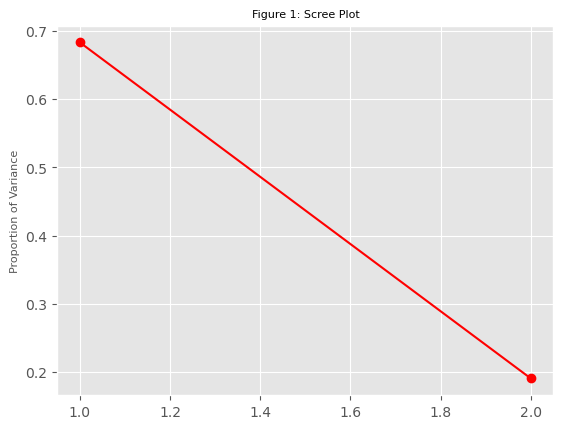

In [3]:

pca = PCA(n_components=2)
pca.fit_transform(hcr_scaled)
prop_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_ 
print(eigenvalues)
print(prop_var)
PC_numbers = np.arange(pca.n_components_) + 1
plt.plot(PC_numbers, prop_var,'ro-')
plt.title('Figure 1: Scree Plot', fontsize=8)
plt.ylabel('Proportion of Variance', fontsize=8)
plt.show()
pca = PCA(n_components=3)
PC = pca.fit_transform(hcr_scaled)



 Varimax FA :

[[-0.27509055  0.75319404]
 [-0.37889737  0.73714596]
 [-0.8680695   0.27064271]
 [-0.8612709   0.29017308]]


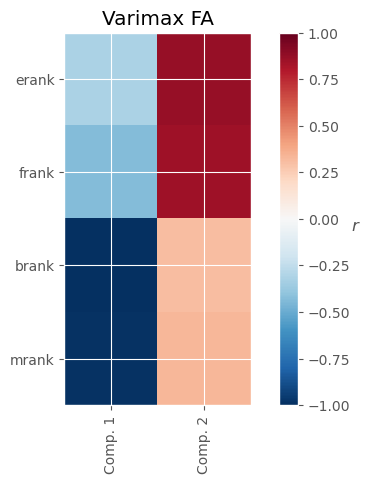

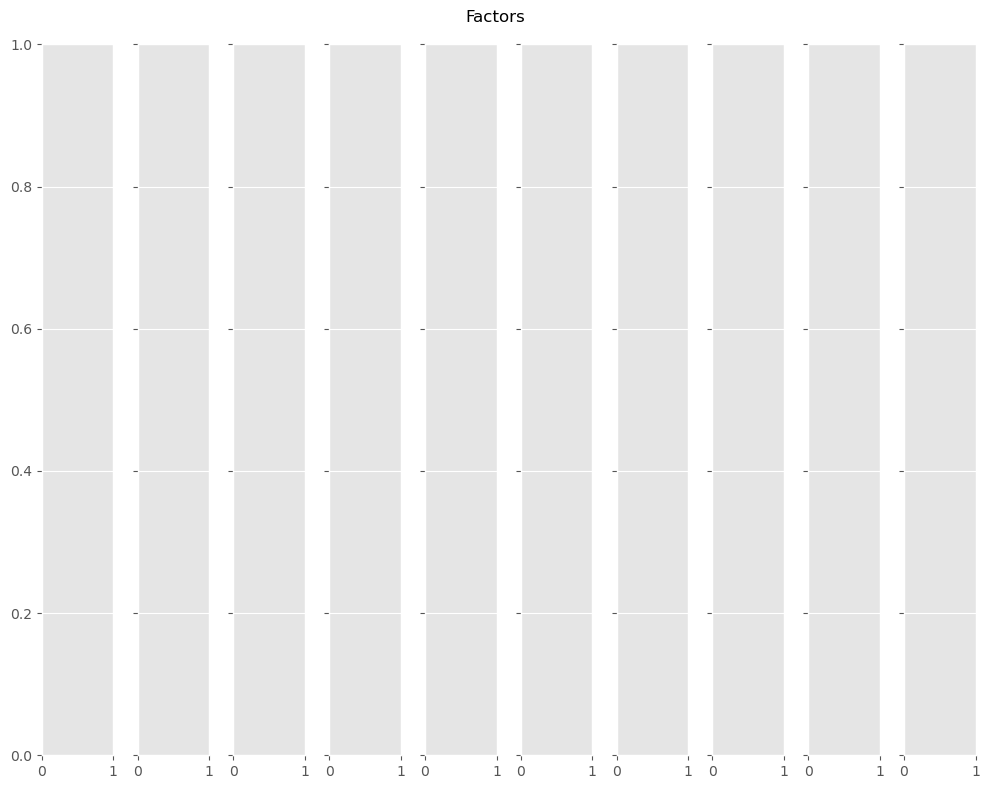

In [4]:
ax = plt.axes()
feature_names = ["erank","frank","brank","mrank"]
im = ax.imshow(np.corrcoef(X.T), cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(list(feature_names), rotation=90)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(list(feature_names))

plt.colorbar(im).ax.set_ylabel("$r$", rotation=0)
ax.set_title("Iris feature correlation matrix")
plt.tight_layout()
n_comps = 2

method = "Varimax FA"
fa = FactorAnalysis(rotation="varimax")
fig, axes = plt.subplots(ncols=len(method), figsize=(10, 8), sharey=True)
fa.set_params(n_components=n_comps)
fa.fit(X)

components = fa.components_.T
print("\n\n %s :\n" % method)
print(components)

vmax = np.abs(components).max()
ax.imshow(components, cmap="RdBu_r", vmax=vmax, vmin=-vmax)
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.set_title(str(method))
ax.set_xticks([0, 1])
ax.set_xticklabels(["Comp. 1", "Comp. 2"])
fig.suptitle("Factors")
plt.tight_layout()
plt.show()

In [5]:
def biplot(score,coef,labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coef.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley,
                s=5, 
                #color='orange')
                color='blue')
    for i in range(n):
        plt.arrow(0, 0, coef[i,0], 
                  coef[i,1],color = 'purple',
                  alpha = 0.5)
        plt.text(coef[i,0], 
                 coef[i,1], 
                 labels[i], 
                 color = 'black', 
                 ha = 'center', 
                 va = 'center')
 
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))    
    plt.figure()


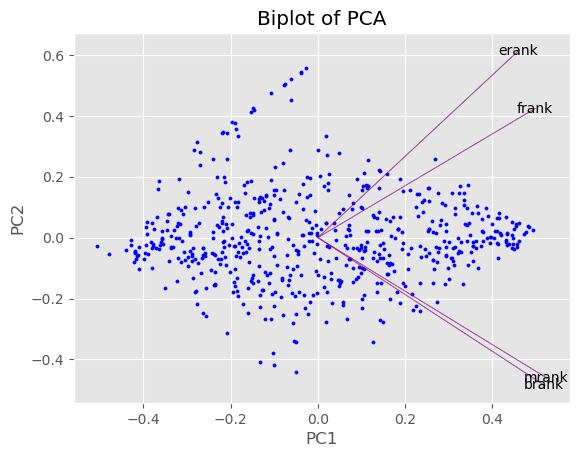

<Figure size 640x480 with 0 Axes>

In [6]:
lolo = data.columns[2:]
plt.title('Biplot of PCA')
biplot(PC,np.transpose(pca.components_),list(lolo))



In [7]:
data.columns

Index(['id', 'ebrank', 'erank', 'frank', 'brank', 'mrank'], dtype='object')

In [8]:
PC

array([[-0.17798453,  3.39128354,  0.45155732],
       [ 1.8264022 ,  1.57625611,  0.21336866],
       [ 1.94296996,  0.6946489 , -0.7049695 ],
       ...,
       [-3.00553246, -0.24327208,  0.23795573],
       [-2.67375432,  0.0711515 ,  0.77820961],
       [-3.27064335, -0.3242231 ,  0.04362273]])

In [9]:
scores = pd.DataFrame(PC)

In [10]:
scores.to_excel('RESULTS/PCA_SCORES.xlsx')